<a href="https://colab.research.google.com/github/varshitfauzdar/AIH_Lab_work/blob/main/LAB2_Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Block 1: Import Required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("/content/archive (1).zip")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
# Block 3: Load Dataset

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
# Block 4: Dataset Information

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Number of Rows: 299
Number of Columns: 13

Column Names:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age          

In [ ]:
# Block 5: Missing Value Summary

missing_values = df.isnull().sum()
missing_values

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
# Block 6: Check Duplicate Rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Block 7: Create Missing Values for Demonstration

df_clean = df.copy()

np.random.seed(42)

# Introduce missing values in numerical columns
for column in ["age", "ejection_fraction", "serum_creatinine", "platelets"]:
    indices = np.random.choice(df_clean.index, size=5, replace=False)
    df_clean.loc[indices, column] = np.nan

print("Artificial missing values introduced for demonstration.")

df_clean.isnull().sum()

Artificial missing values introduced for demonstration.


,0
age,5
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,5
high_blood_pressure,0
platelets,5
serum_creatinine,5
serum_sodium,0
sex,0


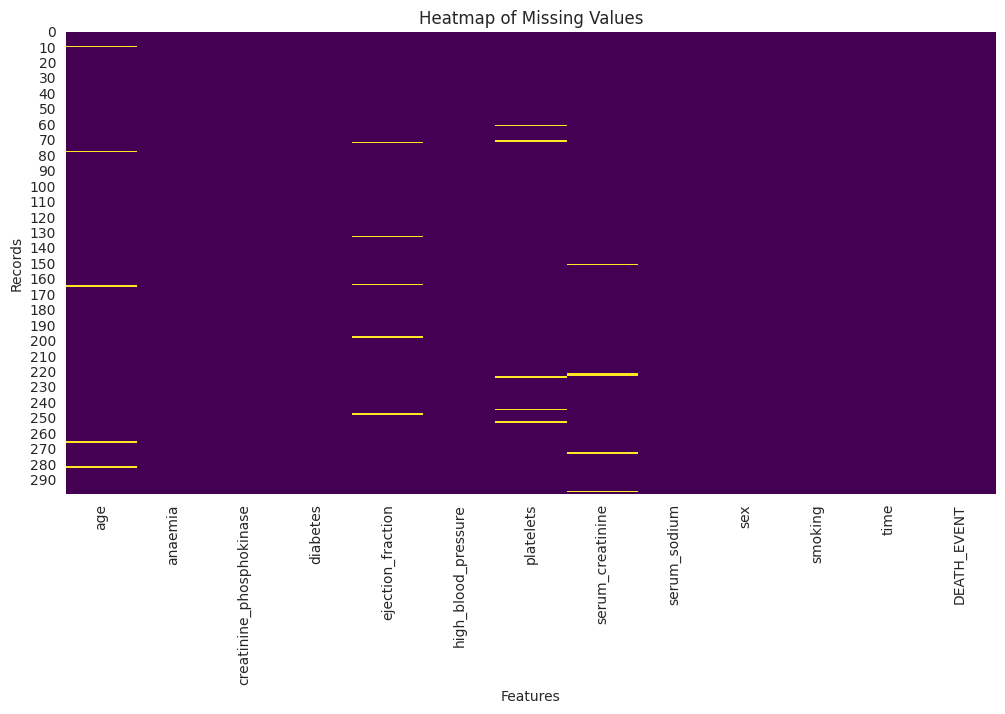

In [ ]:
# Block 8: Missing Value Heatmap

plt.figure(figsize=(12, 6))

sns.heatmap(
    df_clean.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Heatmap of Missing Values")
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

In [ ]:
# Block 9: Identify Numerical Columns

numerical_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical Features:")
print(numerical_columns)

Numerical Features:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


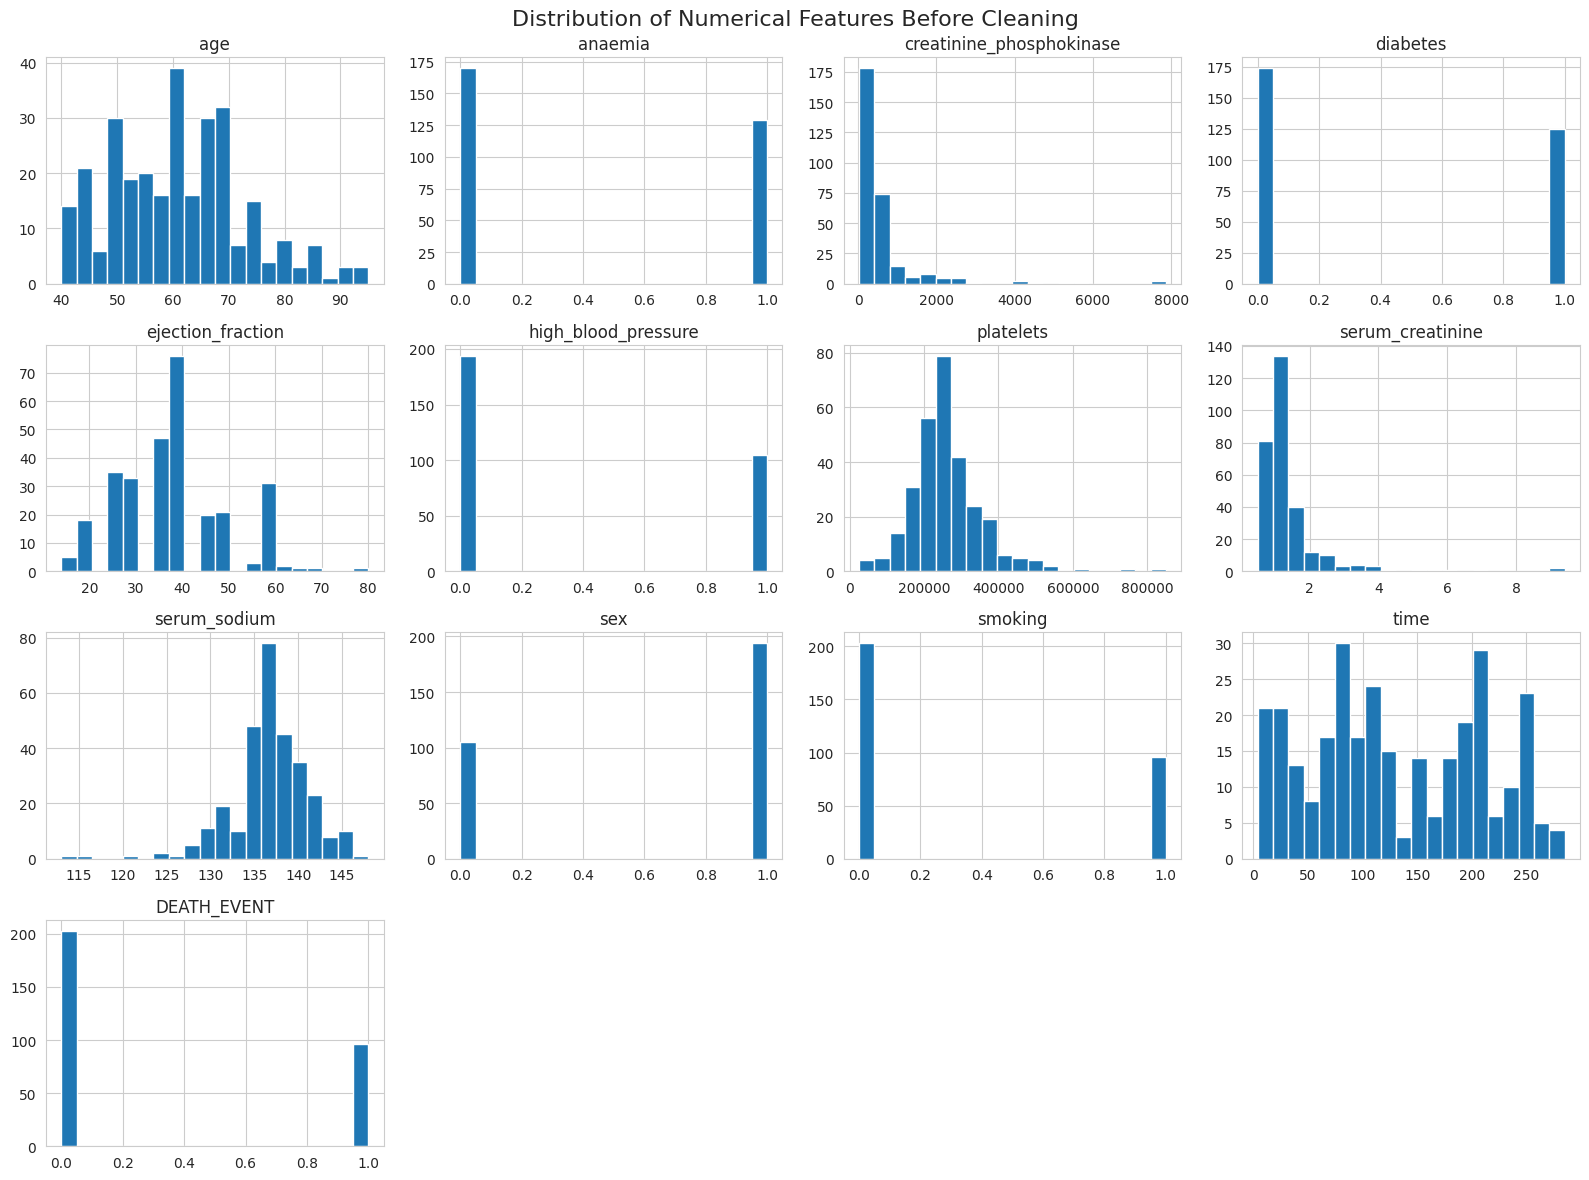

In [ ]:
# Block 10: Histograms of Numerical Features

df_clean[numerical_columns].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features Before Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

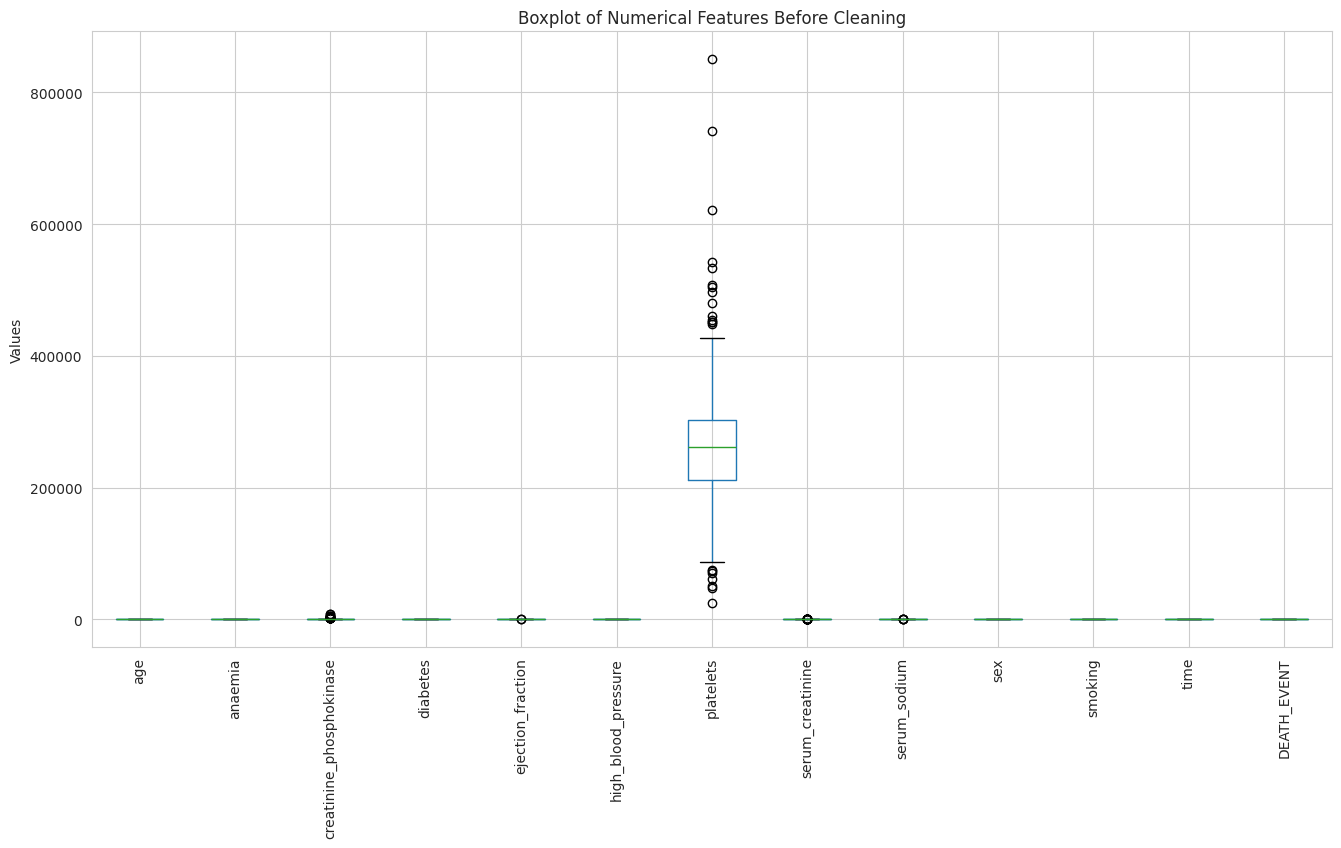

In [ ]:
# Block 11: Boxplots Before Cleaning

plt.figure(figsize=(16, 8))

df_clean[numerical_columns].boxplot()

plt.title("Boxplot of Numerical Features Before Cleaning")
plt.xticks(rotation=90)
plt.ylabel("Values")

plt.show()

In [ ]:
# Block 12: Numerical Missing Value Imputation

for column in numerical_columns:
    if df_clean[column].isnull().sum() > 0:
        median_value = df_clean[column].median()
        df_clean[column] = df_clean[column].fillna(median_value)

print("Missing numerical values imputed using median.")

Missing numerical values imputed using median.


In [ ]:
df_clean.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
# Block 13: Categorical Missing Value Imputation

categorical_columns = df_clean.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:", categorical_columns)

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].mode()[0]
    )

print("Categorical missing values handled.")

Categorical columns: []
Categorical missing values handled.


In [ ]:
# Block 14: Check for Invalid Values

print("Negative Age:", (df_clean["age"] < 0).sum())

print("Negative Serum Creatinine:",
      (df_clean["serum_creatinine"] < 0).sum())

print("Negative Platelets:",
      (df_clean["platelets"] < 0).sum())

print("Invalid Ejection Fraction:",
      ((df_clean["ejection_fraction"] < 0) |
       (df_clean["ejection_fraction"] > 100)).sum())

print("Invalid Serum Sodium:",
      (df_clean["serum_sodium"] <= 0).sum())

Negative Age: 0
Negative Serum Creatinine: 0
Negative Platelets: 0
Invalid Ejection Fraction: 0
Invalid Serum Sodium: 0


In [ ]:
# Block 15: Correct Invalid Entries

# Age cannot be negative
df_clean.loc[df_clean["age"] < 0, "age"] = df_clean["age"].median()

# Ejection fraction should be between 0 and 100
df_clean.loc[
    (df_clean["ejection_fraction"] < 0) |
    (df_clean["ejection_fraction"] > 100),
    "ejection_fraction"
] = df_clean["ejection_fraction"].median()

# Serum creatinine cannot be negative
df_clean.loc[
    df_clean["serum_creatinine"] < 0,
    "serum_creatinine"
] = df_clean["serum_creatinine"].median()

# Platelets cannot be negative
df_clean.loc[
    df_clean["platelets"] < 0,
    "platelets"
] = df_clean["platelets"].median()

# Serum sodium should be positive
df_clean.loc[
    df_clean["serum_sodium"] <= 0,
    "serum_sodium"
] = df_clean["serum_sodium"].median()

print("Invalid entries corrected.")

Invalid entries corrected.


In [ ]:
# Block 16: Detect Outliers using IQR

outlier_summary = {}

for column in numerical_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

outlier_summary

{'age': 0,
 'anaemia': 0,
 'creatinine_phosphokinase': 29,
 'diabetes': 0,
 'ejection_fraction': 2,
 'high_blood_pressure': 0,
 'platelets': 21,
 'serum_creatinine': 28,
 'serum_sodium': 4,
 'sex': 0,
 'smoking': 0,
 'time': 0,
 'DEATH_EVENT': 0}

In [ ]:
# Block 17: Remove Outliers using IQR

df_no_outliers = df_clean.copy()

for column in numerical_columns:

    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[column] >= lower_bound) &
        (df_no_outliers[column] <= upper_bound)
    ]

df_clean = df_no_outliers.reset_index(drop=True)

print("Original rows:", len(df))
print("Rows after outlier removal:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 299
Rows after outlier removal: 225
Rows removed: 74


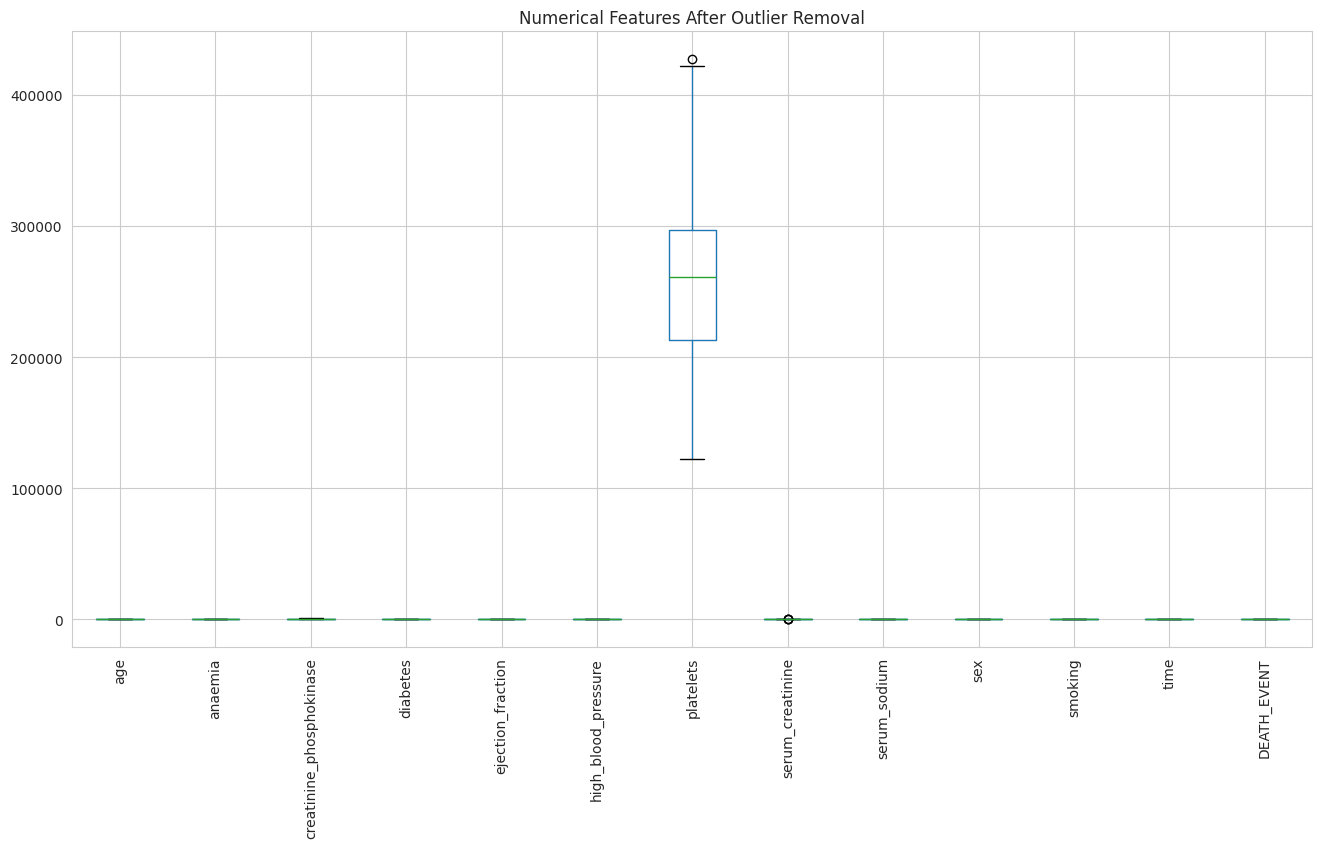

In [ ]:
# Block 18: Boxplot After Outlier Removal

plt.figure(figsize=(16, 8))

df_clean[numerical_columns].boxplot()

plt.title("Numerical Features After Outlier Removal")
plt.xticks(rotation=90)

plt.show()

In [ ]:
# Block 19: Feature Engineering - Age Group

bins = [0, 40, 60, np.inf]
labels = ["<40", "40-60", ">60"]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=bins,
    labels=labels,
    right=False
)

df_clean[["age", "age_group"]].head(10)

,age,age_group
0,75.0,>60
1,65.0,>60
2,50.0,40-60
3,90.0,>60
4,75.0,>60
5,65.0,>60
6,62.0,>60
7,45.0,40-60
8,50.0,40-60
9,49.0,40-60


In [ ]:
# Block 20: Feature Engineering - Risk Score

ef_min = df_clean["ejection_fraction"].min()
ef_max = df_clean["ejection_fraction"].max()

creatinine_min = df_clean["serum_creatinine"].min()
creatinine_max = df_clean["serum_creatinine"].max()

# Higher EF generally indicates better cardiac function,
# so we reverse it for a simple risk-oriented score.

ef_risk = 1 - (
    (df_clean["ejection_fraction"] - ef_min) /
    (ef_max - ef_min)
)

creatinine_risk = (
    (df_clean["serum_creatinine"] - creatinine_min) /
    (creatinine_max - creatinine_min)
)

df_clean["risk_score"] = (
    ef_risk * creatinine_risk
)

df_clean[[
    "ejection_fraction",
    "serum_creatinine",
    "risk_score"
]].head(10)

,ejection_fraction,serum_creatinine,risk_score
0,20.0,1.9,0.764706
1,20.0,1.3,0.411765
2,20.0,1.9,0.764706
3,40.0,2.1,0.490196
4,15.0,1.2,0.392157
5,65.0,1.5,0.000000
6,25.0,0.9,0.156863
7,30.0,1.1,0.228758
8,38.0,1.1,0.176471
9,30.0,1.0,0.183007


In [ ]:
# Block 21: Categorical Features

categorical_columns = df_clean.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical Features:")
print(categorical_columns)

Categorical Features:
['age_group']


In [ ]:
# Block 22: One-Hot Encoding

df_encoded = pd.get_dummies(
    df_clean,
    columns=["age_group"],
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", df_encoded.shape)

df_encoded.head()

Shape after encoding: (225, 16)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,75.0,0,582,0,20.0,1,265000.0,1.9,130,1,0,4,1,0.764706,0,1
1,65.0,0,146,0,20.0,0,162000.0,1.3,129,1,1,7,1,0.411765,0,1
2,50.0,1,111,0,20.0,0,210000.0,1.9,137,1,0,7,1,0.764706,1,0
3,90.0,1,47,0,40.0,1,204000.0,2.1,132,1,1,8,1,0.490196,0,1
4,75.0,1,246,0,15.0,0,127000.0,1.2,137,1,0,10,1,0.392157,0,1


In [ ]:
# Block 23: Save Data Before Normalization

df_before_scaling = df_encoded.copy()

print("Data saved before normalization.")

Data saved before normalization.


In [ ]:
# Block 24: Min-Max Normalization

scaler = MinMaxScaler()

columns_to_scale = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
    "risk_score"
]

df_encoded[columns_to_scale] = scaler.fit_transform(
    df_encoded[columns_to_scale]
)

print("Numerical features normalized successfully.")

# Block 25: Display Normalized Features

df_encoded[columns_to_scale].head()

Numerical features normalized successfully.


,age,anaemia,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,risk_score
0,0.636364,0.0,0.470990,0.117647,0.468852,0.866667,0.217391,0.000000,0.975
1,0.454545,0.0,0.098976,0.117647,0.131148,0.466667,0.173913,0.010676,0.525
2,0.181818,1.0,0.069113,0.117647,0.288525,0.866667,0.521739,0.010676,0.975
3,0.909091,1.0,0.014505,0.509804,0.268852,1.000000,0.304348,0.014235,0.625
4,0.636364,1.0,0.184300,0.019608,0.016393,0.400000,0.521739,0.021352,0.500


In [ ]:
# Block 26: Statistics Before Cleaning

stats_before = df[
    numerical_columns
].agg(["mean", "median", "std"]).T

stats_before.columns = [
    "Mean Before",
    "Median Before",
    "Std Before"
]

stats_before

,Mean Before,Median Before,Std Before
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136


In [ ]:
# Block 27: Statistics After Cleaning

stats_after = df_clean[
    numerical_columns
].agg(["mean", "median", "std"]).T

stats_after.columns = [
    "Mean After",
    "Median After",
    "Std After"
]

stats_after

,Mean After,Median After,Std After
age,60.983707,60.0,11.853488
anaemia,0.466667,0.0,0.500000
creatinine_phosphokinase,336.480000,212.0,278.982528
diabetes,0.417778,0.0,0.494293
ejection_fraction,38.248889,38.0,11.677983
high_blood_pressure,0.382222,0.0,0.487014
platelets,255781.344756,261000.0,66008.417829
serum_creatinine,1.128000,1.1,0.327038
serum_sodium,137.035556,137.0,3.800679
sex,0.640000,1.0,0.481070


In [ ]:
# Block 28: Before vs After Statistics

comparison = pd.concat(
    [stats_before, stats_after],
    axis=1
)

comparison

,Mean Before,Median Before,Std Before,Mean After,Median After,Std After
age,60.833893,60.0,11.894809,60.983707,60.0,11.853488
anaemia,0.431438,0.0,0.496107,0.466667,0.0,0.500000
creatinine_phosphokinase,581.839465,250.0,970.287881,336.480000,212.0,278.982528
diabetes,0.418060,0.0,0.494067,0.417778,0.0,0.494293
ejection_fraction,38.083612,38.0,11.834841,38.248889,38.0,11.677983
high_blood_pressure,0.351171,0.0,0.478136,0.382222,0.0,0.487014
platelets,263358.029264,262000.0,97804.236869,255781.344756,261000.0,66008.417829
serum_creatinine,1.393880,1.1,1.034510,1.128000,1.1,0.327038
serum_sodium,136.625418,137.0,4.412477,137.035556,137.0,3.800679
sex,0.648829,1.0,0.478136,0.640000,1.0,0.481070


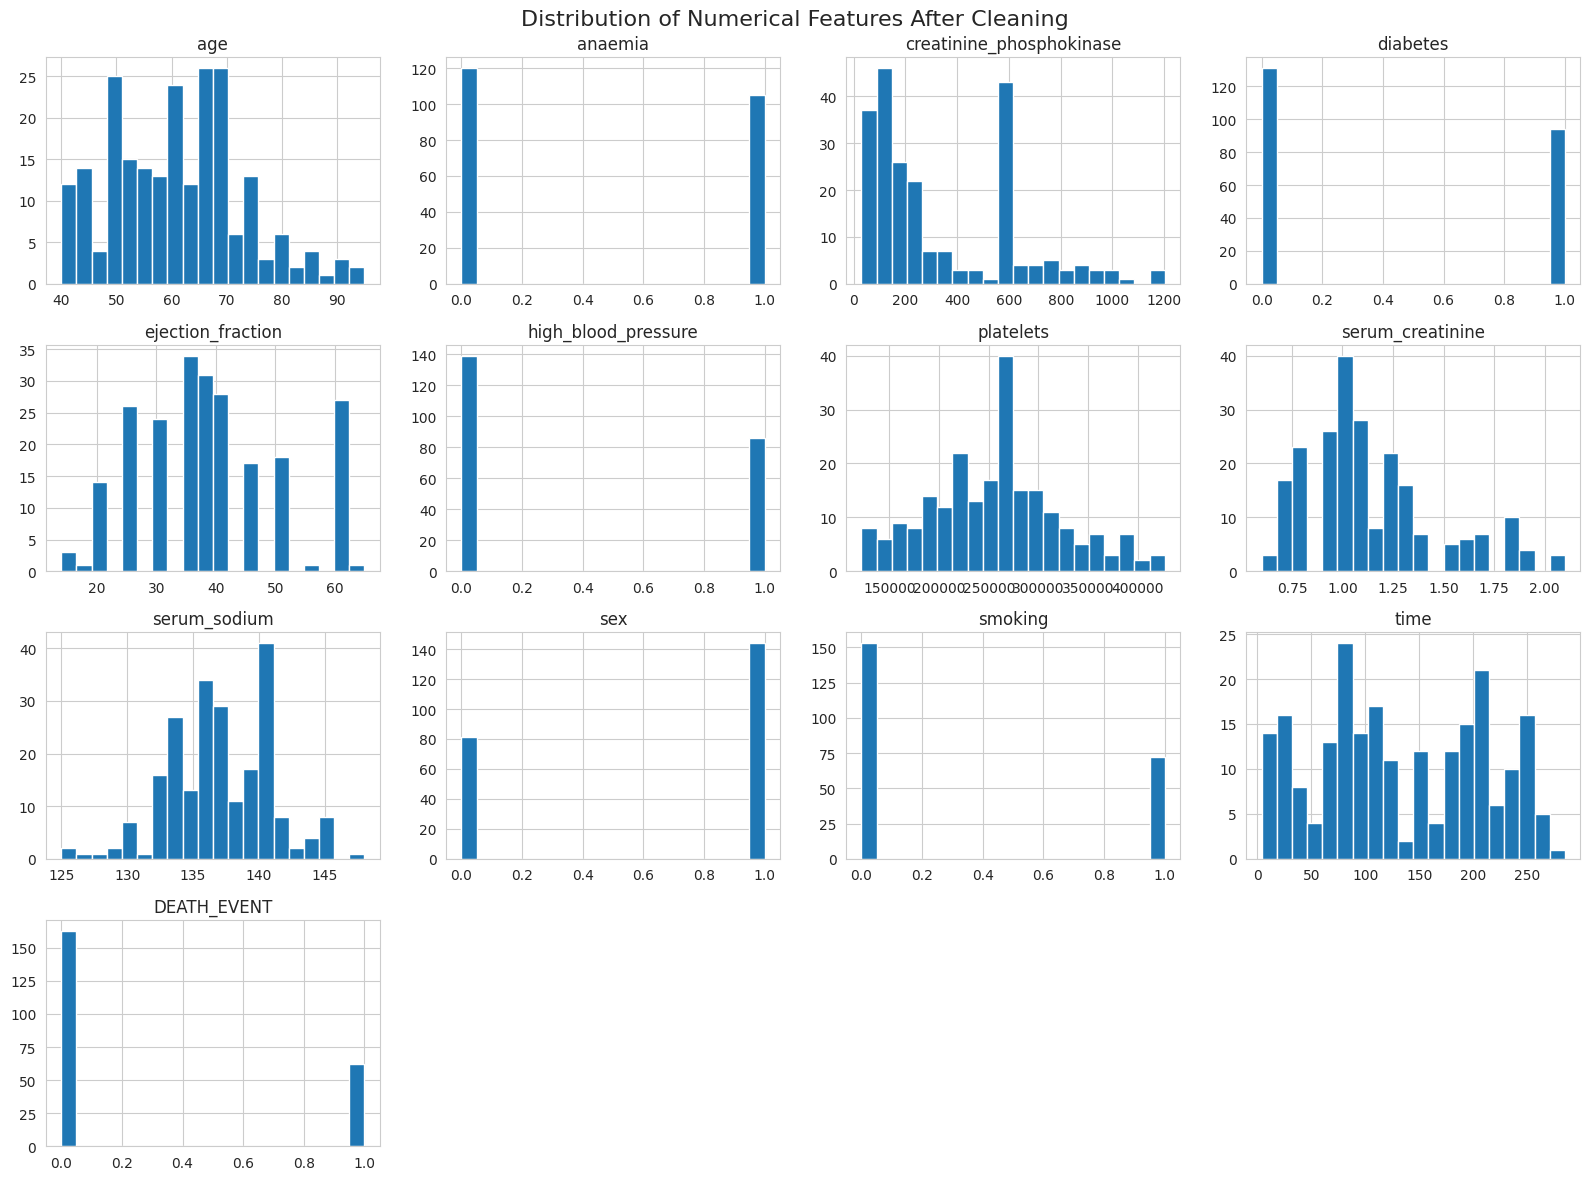

In [ ]:
# Block 29: Histograms After Cleaning

df_clean[numerical_columns].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features After Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

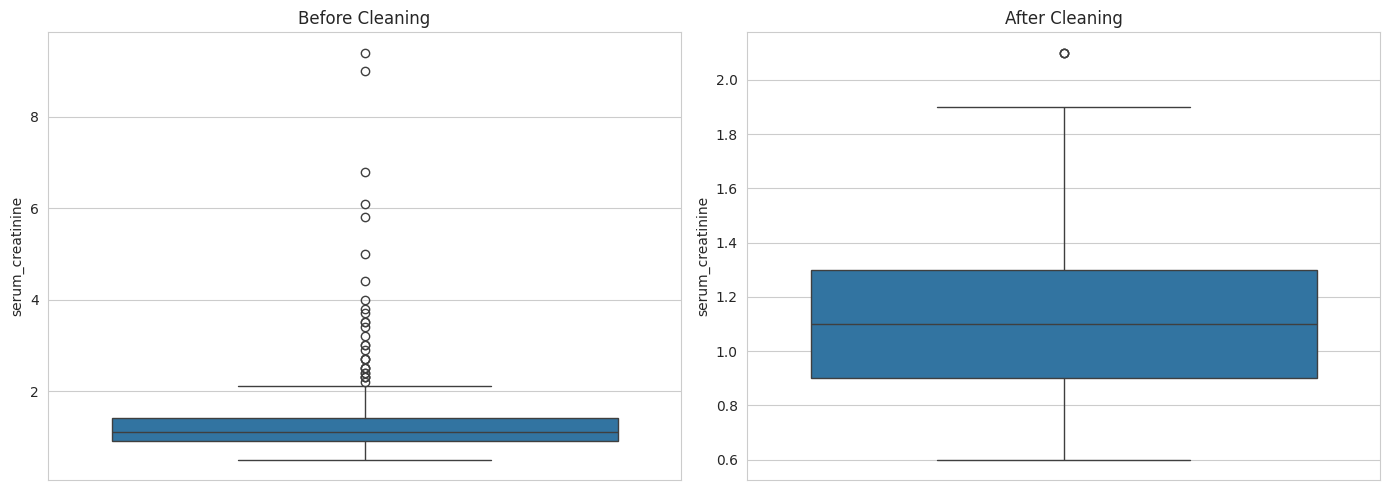

In [ ]:
# Block 30: Compare Important Features

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    y="serum_creatinine",
    ax=axes[0]
)

axes[0].set_title("Before Cleaning")

sns.boxplot(
    data=df_clean,
    y="serum_creatinine",
    ax=axes[1]
)

axes[1].set_title("After Cleaning")

plt.tight_layout()
plt.show()

In [ ]:
# Block 31: Final Missing Value Check

final_missing = df_encoded.isnull().sum()

print("Total Missing Values:",
      final_missing.sum())

print("\nMissing Values by Column:")
print(final_missing)

Total Missing Values: 0

Missing Values by Column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64


In [ ]:
# Block 32: Final Dataset Summary

print("Final Dataset Shape:", df_encoded.shape)

print("\nFinal Columns:")
print(df_encoded.columns.tolist())

print("\nFinal Data Types:")
print(df_encoded.dtypes)

print("\nFirst 5 Rows of Cleaned Dataset:")
display(df_encoded.head())

Final Dataset Shape: (225, 16)

Final Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score', 'age_group_40-60', 'age_group_>60']

Final Data Types:
age                         float64
anaemia                     float64
creatinine_phosphokinase    float64
diabetes                      int64
ejection_fraction           float64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                float64
sex                           int64
smoking                       int64
time                        float64
DEATH_EVENT                   int64
risk_score                  float64
age_group_40-60               int64
age_group_>60                 int64
dtype: object

First 5 Rows of Cleaned Dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,0.636364,0.0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1,0,0.000000,1,0.975,0,1
1,0.454545,0.0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1,1,0.010676,1,0.525,0,1
2,0.181818,1.0,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1,0,0.010676,1,0.975,1,0
3,0.909091,1.0,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1,1,0.014235,1,0.625,0,1
4,0.636364,1.0,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1,0,0.021352,1,0.500,0,1


In [ ]:
# Block 33: Save Final Cleaned Dataset

output_file = "heart_failure_cleaned_dataset.csv"

df_encoded.to_csv(
    output_file,
    index=False
)

print("Cleaned dataset saved as:", output_file)

Cleaned dataset saved as: heart_failure_cleaned_dataset.csv


In [ ]:
# FINAL VERIFICATION

print("=" * 60)
print("HEART FAILURE DATA CLEANING - FINAL REPORT")
print("=" * 60)

print("\nOriginal Dataset Shape:", df.shape)
print("Final Dataset Shape:", df_encoded.shape)

print("\nTotal Missing Values:",
      df_encoded.isnull().sum().sum())

print("Duplicate Rows:",
      df_encoded.duplicated().sum())

print("\nAge Group Created:", "age_group" not in df_encoded.columns)
print("Risk Score Created:", "risk_score" in df_encoded.columns)

print("\nNumerical Features Normalized:")
print(columns_to_scale)

print("\nFinal Dataset Preview:")
display(df_encoded.head())

print("\n" + "=" * 60)
print("DATA CLEANING AND ENRICHMENT COMPLETED SUCCESSFULLY")
print("=" * 60)

HEART FAILURE DATA CLEANING - FINAL REPORT

Original Dataset Shape: (299, 13)
Final Dataset Shape: (225, 16)

Total Missing Values: 0
Duplicate Rows: 0

Age Group Created: True
Risk Score Created: True

Numerical Features Normalized:
['age', 'anaemia', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time', 'risk_score']

Final Dataset Preview:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_40-60,age_group_>60
0,0.636364,0.0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1,0,0.000000,1,0.975,0,1
1,0.454545,0.0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1,1,0.010676,1,0.525,0,1
2,0.181818,1.0,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1,0,0.010676,1,0.975,1,0
3,0.909091,1.0,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1,1,0.014235,1,0.625,0,1
4,0.636364,1.0,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1,0,0.021352,1,0.500,0,1



DATA CLEANING AND ENRICHMENT COMPLETED SUCCESSFULLY
